In [1]:
import numpy as np
import pandas as pd
from mofapy2.run.entry_point import entry_point

np.random.seed(43)
# Barcodes
true_barcodes = (
    open(
        "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/barcodes.csv"
    )
    .read()
    .strip()
    .split(",")[2:]
)

# Timepoints
timepoints = (
    open(
        "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/timepoints.csv"
    )
    .read()
    .strip()
    .split(",")[2:]
)

# Lineages
lineages = (
    open(
        "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/celltypes.csv"
    )
    .read()
    .strip()
    .split(",")[2:]
)


x_bc_3d = np.load(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_bc.npy"
)

# Flatten
x_bc_2d = x_bc_3d.reshape(x_bc_3d.shape[0], -1)

# Fate feature names
fate_features = [
    f"{t}_{l}"
    for t in timepoints
    for l in lineages
]

# Fate dataframe
df_fate = pd.DataFrame(
    np.log2(x_bc_2d + 1),
    index=true_barcodes,
    columns=fate_features
)

## CHANGING O.5 TO 0.8 - SAME VAR USED IN NMF. used 0.0 for prev analysis. going to 08 for 1-1 comparison of no. of overlapping genes

df_rna = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_rna_variance_0.80.csv",
    index_col=0
)


df_adt = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_adt.csv",
    index_col=0
)

# Force matching barcodes
df_rna.index = true_barcodes
df_adt.index = true_barcodes

# getting rid of zero var cells - 
df_rna = df_rna.loc[:, df_rna.var() > 0]
df_adt = df_adt.loc[:, df_adt.var() > 0]
df_fate = df_fate.loc[:, df_fate.var() > 0]

print(f"Remaining RNA features: {df_rna.shape[1]}")
print(f"Remaining ADT features: {df_adt.shape[1]}")
print(f"Remaining Fate features: {df_fate.shape[1]}")


feat_rna = df_rna.columns.tolist()
feat_adt = df_adt.columns.tolist()
feat_fate = df_fate.columns.tolist()



mat_rna = df_rna.values.astype(np.float64)
mat_adt = df_adt.values.astype(np.float64)
mat_fate = df_fate.values.astype(np.float64)

# Nested structure:
# views -> groups
data_nested_matrix = [
    [mat_rna],
    [mat_adt],
    [mat_fate]
]
assert list(df_rna.index) == list(df_adt.index)
assert list(df_rna.index) == list(df_fate.index)

# Run MOFA

ent = entry_point()

ent.set_data_options(
    scale_views=True
)

ent.set_data_matrix(
    data_nested_matrix,
    likelihoods=["gaussian", "gaussian", "gaussian"],
    views_names=["RNA", "ADT", "Fate_Tracking"],
    groups_names=["single_group"],
    samples_names=[true_barcodes],
    features_names=[feat_rna, feat_adt, feat_fate]
)

ent.set_model_options(
    factors=15,
    spikeslab_weights=True
)

ent.set_train_options(
    convergence_mode="medium",
    iter=1000,
    verbose=True,
    seed=43,
    dropR2=0.001
)

ent.build()
ent.run()


# ent.save(
#     "zero_var_mofa.hdf5",
#     save_data=True
# )

Remaining RNA features: 4674
Remaining ADT features: 163
Remaining Fate features: 40

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Scaling views to unit variance...

Successfully loaded view='RNA' group='single_group' with N=112 samples and D=4674 features...
Successfully loaded view='ADT' group='single_group' with N=112 samples and D=163 features...
Successfully loaded view='Fate_Tracking' group='single_group' with N=112 samples 

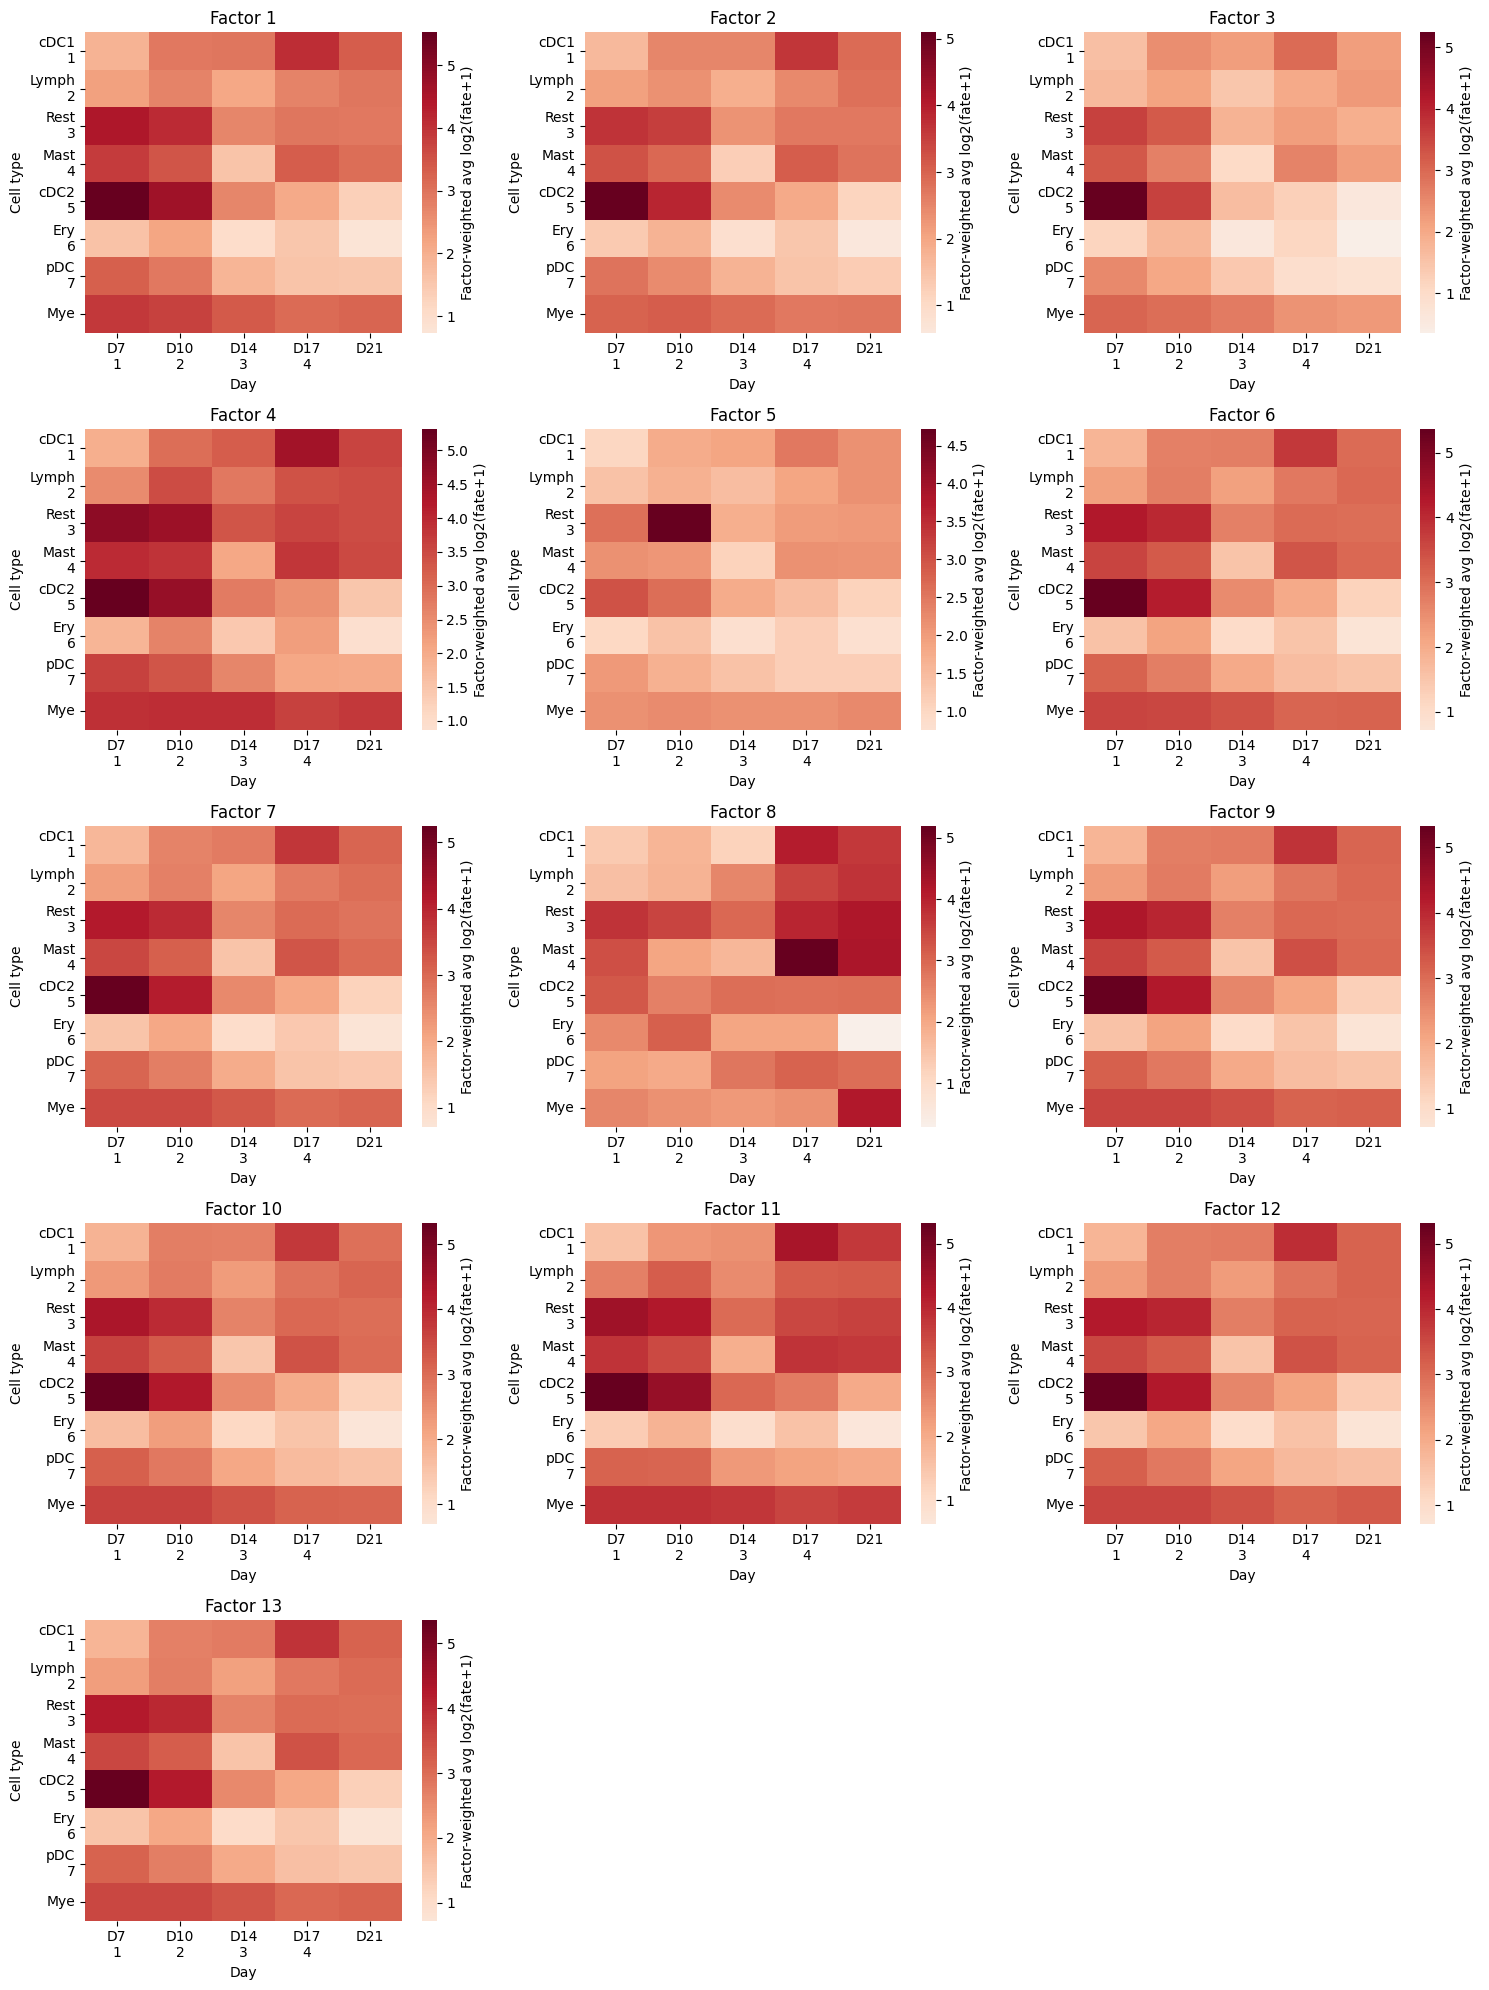

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Z = ent.model.getExpectations()["Z"]["E"]

if Z.shape[0] != len(true_barcodes):
    Z = Z.T
assert Z.shape[0] == len(true_barcodes)

X_lineage = x_bc_3d  # barcodes x timepoints x lineages, same order as true_barcodes
n_factors = Z.shape[1]

ncols = 3
nrows = int(np.ceil(n_factors / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.ravel(axes)

for k in range(n_factors):
    weights = Z[:, k]
    weights = weights - weights.min()   # shift so weights are non-negative
    weights = weights / weights.sum()   # normalize to sum to 1

    # weighted avg over barcodes -> (timepoints, lineages)
    avg = np.tensordot(weights, X_lineage, axes=(0, 0))

    sns.heatmap(
        avg.T,                  # -> (lineages, timepoints), so day=x, celltype=y
        ax=axes[k],
        cmap="RdBu_r",
        center=0,
        xticklabels=timepoints,
        yticklabels=lineages,
        cbar_kws={"label": "Factor-weighted avg log2(fate+1)"},
    )
    axes[k].set_title(f"Factor {k+1}")
    axes[k].set_xlabel("Day")
    axes[k].set_ylabel("Cell type")

for ax in axes[n_factors:]:
    ax.axis("off")

plt.tight_layout()

varimax not useful 


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer.rotator import Rotator

# --- 1) Pull Z and W for every view ---
exp = ent.model.getExpectations()

Z_orig = exp["Z"]["E"] if isinstance(exp["Z"], dict) else exp["Z"]

# W is a list of per-view dicts, each with an "E" key
W_list_orig = [w["E"] for w in exp["W"]]
  # list: [W_rna, W_adt, W_fate]

view_names = ["RNA", "ADT", "Fate_Tracking"]
data_list = [mat_rna, mat_adt, mat_fate]  # original matrices, same order as views_names

if Z_orig.shape[0] != len(true_barcodes):
    Z_orig = Z_orig.T

# --- 2) Concatenate loadings across ALL views before rotating ---
W_concat = np.concatenate(W_list_orig, axis=0)  # (total_features x factors)

rotator = Rotator(method="varimax")
W_concat_rot = rotator.fit_transform(W_concat)
R = rotator.rotation_
Z_rot = Z_orig @ R

# --- 3) Split rotated loadings back into per-view chunks ---
split_idx = np.cumsum([w.shape[0] for w in W_list_orig])[:-1]
W_rot_list = np.split(W_concat_rot, split_idx, axis=0)

print("Z_rot:", Z_rot.shape)
for name, w in zip(view_names, W_rot_list):
    print(f"W_rot[{name}]:", w.shape)

Z_rot: (112, 13)
W_rot[RNA]: (4674, 13)
W_rot[ADT]: (163, 13)
W_rot[Fate_Tracking]: (40, 13)


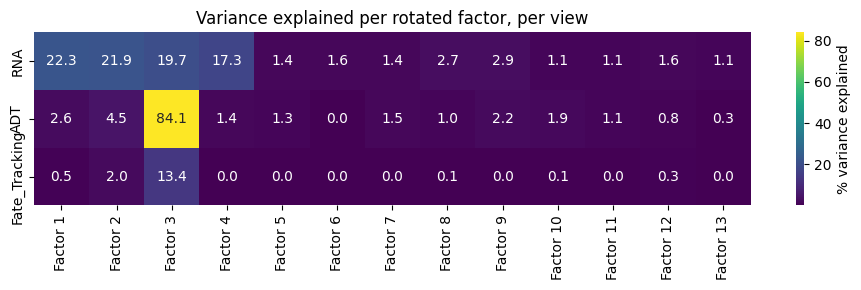

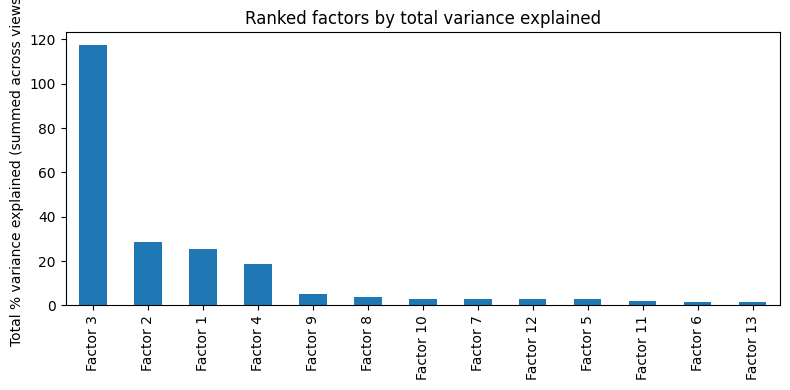

In [13]:
def r2_per_factor(Y, Z, W):
    """% variance of Y explained by each factor individually."""
    Y_c = Y - Y.mean(axis=0, keepdims=True)
    ss_tot = np.sum(Y_c ** 2)
    r2s = []
    for k in range(Z.shape[1]):
        Y_pred_k = np.outer(Z[:, k], W[:, k])
        ss_k = np.sum(Y_pred_k ** 2)
        r2s.append(100 * ss_k / ss_tot)
    return np.array(r2s)

n_factors = Z_rot.shape[1]
r2_matrix = np.zeros((len(view_names), n_factors))

for i, (Y, W) in enumerate(zip(data_list, W_rot_list)):
    r2_matrix[i, :] = r2_per_factor(Y, Z_rot, W)

r2_df = pd.DataFrame(
    r2_matrix,
    index=view_names,
    columns=[f"Factor {k+1}" for k in range(n_factors)]
)

# Heatmap: variance explained per factor, per view
plt.figure(figsize=(0.5 * n_factors + 3, 3))
sns.heatmap(r2_df, cmap="viridis", annot=True, fmt=".1f", cbar_kws={"label": "% variance explained"})
plt.title("Variance explained per rotated factor, per view")
plt.tight_layout()
plt.show()

# Bar plot: total variance explained per factor (summed across views), sorted
total_r2 = r2_df.sum(axis=0).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
total_r2.plot(kind="bar")
plt.ylabel("Total % variance explained (summed across views)")
plt.title("Ranked factors by total variance explained")
plt.tight_layout()
plt.show()


fate riving most variance in data by leages and miles. 

## finding matching factors
using one to one overlap of factors

In [50]:
nmf_loadings = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/files/nmf_loadings.csv",
)

nmf_activities = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/files/nmf_activities.csv",
)
nmf_genes = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/files/nmf_genes.csv",
).iloc[:, 0].values
print("nmf_loadings shape:", nmf_loadings.shape)
print("nmf_activities shape:", nmf_activities.shape)
print("nmf_genes shape:", nmf_genes.shape)
print("nmf_genes sample:", nmf_genes[:5])

print("is nmf_loadings.shape[0] != len(nmf_genes)?",nmf_loadings.shape[0] != len(nmf_genes))

nmf_loadings shape: (1737, 17)
nmf_activities shape: (112, 17)
nmf_genes shape: (1737,)
nmf_genes sample: ['ISG15' 'TNFRSF4' 'PRDM16' 'SMIM1' 'MIR34AHG']
is nmf_loadings.shape[0] != len(nmf_genes)? False


In [51]:
print(len(nmf_genes))
nmf_activities.shape

1737


(112, 17)

In [52]:
nmf_loadings

,Unnamed: 0,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,Factor_11,Factor_12,Factor_13,Factor_14,Factor_15,Factor_16
0,ISG15,2.270975e-02,3.261161e+00,7.906161e-02,8.092179e-18,8.188179e-10,1.664350e+00,4.328795e+00,4.748439e+00,2.863091e-11,2.893634e+00,6.025767e+00,3.867501e-01,3.467469e-18,7.563318e-19,1.850728e+00,6.492416e-10
1,TNFRSF4,8.203796e-44,6.580270e-62,2.518088e-121,2.050101e-16,3.638944e-36,2.921160e+00,4.576626e-157,2.873837e-55,4.397058e-71,6.694516e-01,1.202283e-13,3.697541e-59,7.735145e-28,4.120750e-11,5.111607e+00,3.658722e+00
2,PRDM16,4.247729e-88,3.137846e-154,1.546177e-160,1.559696e-51,6.300826e-181,5.070950e+00,3.898342e-74,2.643030e-143,7.903346e-196,2.189124e-68,3.990808e-06,1.773283e-165,3.435719e-100,1.172485e-159,3.826263e+00,4.031882e+00
3,SMIM1,3.692652e-01,3.908450e-01,7.945829e-03,4.535792e-115,2.581544e-256,3.091215e-64,3.377753e-33,8.503106e-67,1.527283e-49,2.164708e-12,3.501426e-54,2.659242e-01,8.071265e-06,1.019738e-30,1.418921e-01,3.471197e-85
4,MIR34AHG,2.383660e-306,9.401135e-01,5.564848e-12,0.000000e+00,7.580664e-59,4.128340e-199,1.175047e-94,3.287504e-16,4.336918e-07,4.802124e-46,8.827284e-72,5.462233e-65,4.838907e-36,7.877066e-77,1.193045e-17,1.201013e-303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1732,MT-CO1,6.277236e+00,6.722957e+01,2.971636e+01,1.138238e+01,1.866637e+01,1.391748e+01,3.062751e+01,5.095241e+01,2.061922e+01,3.282221e+01,7.599774e+00,1.021128e+01,4.463047e+01,1.679087e+01,5.033255e+01,1.431605e+01
1733,MT-ATP6,7.698109e+00,6.413150e+01,2.546942e+01,1.316644e+01,1.655985e+01,1.253542e+01,2.269232e+01,3.848181e+01,2.797198e+01,2.492357e+01,5.184436e+00,6.410755e+00,4.452201e+01,1.844836e+01,4.806735e+01,1.242213e+01
1734,MT-CO3,6.386600e+00,6.620320e+01,2.999910e+01,1.086641e+01,1.917557e+01,1.370330e+01,3.310699e+01,4.974127e+01,2.833869e+01,2.613479e+01,7.508178e+00,7.805676e+00,4.061687e+01,1.921685e+01,4.835201e+01,1.236061e+01
1735,MT-ND4,6.621479e+00,5.846222e+01,2.652736e+01,1.084752e+01,1.248815e+01,8.925483e+00,2.330836e+01,4.380974e+01,2.605818e+01,1.930900e+01,6.721224e+00,6.933616e+00,3.982978e+01,1.500506e+01,3.585198e+01,1.083175e+01


In [53]:
import pandas as pd
from io import StringIO

raw = """Gene	Factor	Entry	omics
NKAIN2	factor_3	Q5VXU1	rna
CALN1	factor_3	Q9BXU9	rna
ANGPT1	factor_3	Q15389	rna
ATP8B4	factor_3	Q8TF62	rna
INPP4B	factor_3	O15327	rna
FTH1	factor_3	P02794	rna
MSI2	factor_3	Q96DH6	rna
MECOM	factor_3	Q03112	rna
ERG	factor_3	P11308	rna
S100A4	factor_3	P26447	rna
NPM1	factor_3	P06748	rna
FTL	factor_3	P02792	rna
VAV3	factor_3	Q9UKW4	rna
PRDX1	factor_3	Q06830	rna
RUNX1	factor_3	Q01196	rna
RIPOR2	factor_3	Q9Y4F9	rna
CCDC171	factor_3	Q6TFL3	rna
MALAT1	factor_3	NA	rna
ADK	factor_3	P55263	rna
GAPDH	factor_3	P04406	rna
ABLIM1	factor_3	O14639	rna
LRBA	factor_3	P50851	rna
CD164	factor_3	Q04900	rna
NR6A1	factor_3	Q15406	rna
CARMIL1	factor_3	Q5VZK9	rna
TMEM163	factor_3	Q8TC26	rna
SMYD3	factor_3	Q9H7B4	rna
RBPMS	factor_3	Q93062	rna
NRIP1	factor_3	P48552	rna
HOPX	factor_3	Q9BPY8	rna
MIR181A1HG	factor_20	NA	rna
LTB	factor_20	Q06643	rna
AFF3	factor_20	P51826	rna
UBE2E2	factor_20	Q96LR5	rna
TOX	factor_20	O94900	rna
CD74	factor_20	P04233	rna
ARHGAP25	factor_20	P42331	rna
MBD5	factor_20	Q9P267	rna
BCL2	factor_20	P10415	rna
MED13L	factor_20	Q71F56	rna
HDAC9	factor_20	Q9UKV0	rna
FER	factor_20	P16591	rna
TAOK3	factor_20	Q9H2K8	rna
KCNQ5	factor_20	Q9NR82	rna
R3HDM2	factor_20	Q9Y2K5	rna
MEF2C	factor_20	Q06413	rna
ARHGAP15	factor_20	Q53QZ3	rna
ST6GAL1	factor_20	P15907	rna
MPO	factor_20	P05164	rna
STK39	factor_20	Q9UEW8	rna
HSPA5	factor_20	P11021	rna
MAPK8	factor_20	P45983	rna
PHIP	factor_20	Q8WWQ0	rna
TAF15	factor_20	Q16514	rna
PHACTR1	factor_20	Q9C0D0	rna
NSD2	factor_20	O96028	rna
NOLC1	factor_20	Q14978	rna
C1QTNF4	factor_20	Q9BXJ3	rna
CNTNAP2	factor_1	Q9UHC6	rna
CACNB4	factor_1	O00305	rna
CAMK1D	factor_1	Q8IU85	rna
CYP1B1	factor_1	Q16678	rna
PAN3	factor_1	Q58A45	rna
VWA8	factor_1	A3KMH1	rna
CYP51A1	factor_1	Q16850	rna
TCF4	factor_1	P15884	rna
LDHA	factor_1	P00338	rna
TCF7L2	factor_1	Q9NQB0	rna
MDFIC	factor_1	Q9P1T7	rna
SAMSN1	factor_1	Q9NSI8	rna
CD109	factor_1	Q6YHK3	rna
DPYD	factor_1	Q12882	rna
E2F3	factor_1	O00716	rna
GSTCD	factor_1	Q8NEC7	rna
CCSER1	factor_1	Q9C0I3	rna
H2AFZ	factor_6	P0C0S5	rna
PTMA	factor_6	P06454	rna
HMGB1	factor_6	P09429	rna
TUBA1B	factor_6	P68363	rna
HSP90AA1	factor_6	P07900	rna
HSP90AB1	factor_6	P08238	rna
TMSB4X	factor_6	P62328	rna
STXBP5	factor_6	Q5T5C0	rna
YBX1	factor_6	P67809	rna
ODC1	factor_6	P11926	rna
HMGN2	factor_6	P05204	rna
HNRNPAB	factor_6	Q99729	rna
ZEB2	factor_6	O60315	rna
HSPD1	factor_6	P10809	rna
PTGES3	factor_6	Q15185	rna
HMGB2	factor_6	P26583	rna
DUT	factor_6	P33316	rna
NUCKS1	factor_6	Q9H1E3	rna
CALR	factor_6	P27797	rna
HNRNPA3	factor_6	P51991	rna
IMMP2L	factor_9	Q96T52	rna
FCHSD2	factor_9	O94868	rna
LGALS1	factor_9	P09382	rna
LPCAT2	factor_9	Q7L5N7	rna
KHDRBS2	factor_9	Q5VWX1	rna
GSTP1	factor_9	P09211	rna
FHIT	factor_9	P49789	rna
SCLT1	factor_9	Q96NL6	rna
VIM	factor_9	P08670	rna
SUPT3H	factor_9	O75486	rna
EIF1AX	factor_9	P47813	rna
MANF	factor_9	P55145	rna
COG5	factor_9	Q9UP83	rna
MIR924HG	factor_9	NA	rna
GRK3	factor_9	P35626	rna
TM7SF3	factor_9	Q9NS93	rna
ZFP36L2	factor_10	P47974	rna
DYNLL1	factor_10	P63167	rna
MIF	factor_10	P03971	rna
ITGA4	factor_10	P13612	rna
PLEKHA5	factor_10	Q9HAU0	rna
ZCCHC7	factor_10	Q8N3Z6	rna
SQLE	factor_10	Q14534	rna
ENO1	factor_10	P06733	rna
TOP2A	factor_10	P11388	rna
FDPS	factor_10	P14324	rna
FABP5	factor_12	Q01469	rna
CALM2	factor_12	P0DP24	rna
C1QBP	factor_12	Q07021	rna
LST1	factor_12	O00453	rna
ITM2A	factor_14	O43736	rna
EPB41L3	factor_14	Q9Y2J2	rna
RAD51B	factor_14	O15315	rna
WWOX	factor_14	Q9NZC7	rna
DOCK10	factor_14	Q96BY6	rna
STMN1	factor_14	P16949	rna
CYSLTR1	factor_14	Q9Y271	rna
MBNL1	factor_14	Q9NR56	rna
ERVMER61-1	factor_14	NA	rna
NCL	factor_14	P19338	rna
NPM3	factor_14	O75607	rna
SPIDR	factor_14	Q14159	rna
EIF4G3	factor_14	O43432	rna
SLC35F1	factor_15	Q5T1Q4	rna
SERPINB1	factor_15	P30740	rna
HOXA9	factor_15	P31269	rna
SPINK2	factor_15	P20155	rna
PCLAF	factor_15	Q15004	rna
ETV6	factor_15	P41212	rna
IGFBP7	factor_15	Q16270	rna
RNF220	factor_15	Q5VTB9	rna
NME1	factor_15	P15531	rna
NUCB2	factor_15	P80303	rna
CASC15	factor_16	NA	rna
MAP7	factor_16	Q14244	rna
CPNE8	factor_16	Q86YQ8	rna
CHRM3	factor_16	P20309	rna
GYPC	factor_16	P04921	rna
SPTBN1	factor_16	Q01082	rna
TUBB	factor_16	P07437	rna
CD81	factor_0	P60033	adt
NRP1	factor_0	O14786	adt
CD48	factor_0	P09326	adt
CD58	factor_0	P19256	adt
CD47	factor_0	Q08722	adt
SELPL	factor_0	Q14242	adt
PTPRC	factor_0	P08575	adt
FAS	factor_0	P25445	adt
IFNGR1	factor_0	P15260	adt
PECAM1	factor_1	P16284	adt
CD305	factor_1	Q6GTX8	adt
CD9	factor_1	P21926	adt
CD99	factor_1	P14209	adt
CD11A	factor_1	P20701	adt
IL3R	factor_1	P26951	adt
NECTIN2	factor_1	Q92692	adt
ITGA6	factor_2	P23229	adt
ITGB7	factor_2	NA	adt
HLA-II	factor_2	NA	adt
CD13	factor_2	P15144	adt
PVR	factor_3	P15151	adt
CD244	factor_3	Q9BZW8	adt
ICOSLG	factor_3	O75144	adt
GPR56	factor_3	Q9Y653	adt
CD43	factor_4	P16150	adt
ITGB1	factor_4	P05556	adt
CD84	factor_5	Q9UIB8	adt
CD151	factor_6	P48509	adt
CD82	factor_6	P27701	adt
CD72	factor_6	P21854	adt
CD33	factor_7	P20138	adt
CD93	factor_8	Q9NPY3	adt
CD44	factor_9	P16070	adt
SELL	factor_9	P14151	adt
LAMP1	factor_10	P11279	adt
CCR2	factor_10	P41597	adt
TFRC	factor_10	P02786	adt
CD200	factor_11	P41217	adt
TNFRSF4	factor_14	P43489	adt
NCAM1	factor_15	P13591	adt
CD49B	factor_15	P17301	adt
ITGAE	factor_18	P38570	adt
THBD	factor_18	P07204	adt
CD101	factor_18	Q93033	adt
CD18	factor_21	P05107	adt
IRF8		Q02556	control
BATF3		Q9NR55	control
SPI1		P17947	control
MPO		P05164	control
CSF1R		P07333	control
CEBPA		P49715	control
BCL11A		Q9H165	control
IKZF1 		Q13422	control
GATA1		P15976	control"""

df = pd.read_csv(StringIO(raw), sep="\t")
df.columns = ["Gene", "Factor", "Entry", "omics"]
df["Gene"] = df["Gene"].astype(str).str.strip()
df["omics"] = df["omics"].astype(str).str.strip()

sara_genes = df["Gene"].tolist()

rna_genes = set(df[df["omics"] == "rna"]["Gene"])
adt_genes = set(df[df["omics"] == "adt"]["Gene"])
control_genes = set(df[df["omics"] == "control"]["Gene"])
print("rna_genes:", len(rna_genes))

rna_genes: 155


In [54]:

# done to try find the 113 missing genes in total mofa count. 
df_rna_copy = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_rna_variance_0.40.csv",
    index_col=0
)
df_adt_copy = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_adt.csv",
    index_col=0
)
feat_rna_with_var  = df_rna_copy.columns.tolist()
feat_adt_v = df_adt_copy.columns.tolist()
len(feat_rna_with_var)
len(feat_rna)
common_genes_r = set(sorted(set(nmf_genes) & set(feat_rna_with_var)))
common_genes_u = set(sorted(set(nmf_genes) & set(feat_adt_v)))

#all_genes_present = set(all_genes).issubset(feat_rna_with_var)

print("!!!!check")
#print(all_genes_present)
print("!!!!")
common_genes = common_genes_r | common_genes_u
print(f"Common genes: {len(common_genes)} (NMF had {len(nmf_genes)}, MOFA RNA had {len(feat_rna_with_var)})")

rna_names_in_nmf = set(nmf_genes) & set(feat_rna_with_var)
adt_names_in_nmf = set(nmf_genes) & set(feat_adt_v)
neither = set(nmf_genes) - set(feat_rna_with_var) - set(feat_adt_v)

print(f"NMF names matching MOFA RNA genes: {len(rna_names_in_nmf)}")
print(f"NMF names matching ADT protein names: {len(adt_names_in_nmf)}")
print(f"NMF names matching neither: {len(neither)}")
print("\nSample of 'neither' names:", sorted(neither)[:20])

!!!!check
!!!!
Common genes: 1719 (NMF had 1737, MOFA RNA had 16177)
NMF names matching MOFA RNA genes: 1719
NMF names matching ADT protein names: 0
NMF names matching neither: 18

Sample of 'neither' names: ['MT-ATP6', 'MT-CO1', 'MT-CO3', 'MT-ND2', 'MT-ND4', 'MT-ND5', 'MT1E', 'MT2A', 'MTERF1', 'MTHFD1L', 'MTSS1', 'MTUS2', 'RPL22L1', 'RPL34-AS1', 'RPS27L', 'RPS4Y1', 'RPS6KA3', 'RPS6KA5']


In [55]:

df_rna_raw = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed/X_rna.csv", 
    index_col=0
)

neither = sorted(set(nmf_genes) - set(feat_rna) - set(feat_adt_v))
found_in_raw = [g for g in neither if g in df_rna_raw.columns]
missing_everywhere = [g for g in neither if g not in df_rna_raw.columns]

print(f"Of the 219 'neither' genes: {len(found_in_raw)} found in raw RNA matrix, {len(missing_everywhere)} not found anywhere")

if found_in_raw:
    variances = df_rna_raw[found_in_raw].var()
    print("Variance of these genes in current raw matrix (should mostly be 0 if var-filtering explains it):")
    print(variances.sort_values().head(10))
    print(variances.sort_values(ascending=False).head(10))

Of the 219 'neither' genes: 57 found in raw RNA matrix, 0 not found anywhere
Variance of these genes in current raw matrix (should mostly be 0 if var-filtering explains it):
ABCD2         0.000000
LINC00944     0.000000
MYO3A         0.000000
GABRA3        0.000016
SCAT1         0.000016
AF123462.1    0.000146
LINC01692     0.000146
HPN           0.000171
TRBC1         0.000247
LINC02363     0.000799
dtype: float64
RPS4Y1     1.170479
MTSS1      0.601252
RPL22L1    0.461447
RPS6KA5    0.389884
MTHFD1L    0.331875
RPS27L     0.315251
RPS6KA3    0.275478
TLCD4      0.234358
MT-ND5     0.217309
MT-ATP6    0.165293
dtype: float64


In [69]:
print(nmf_loadings.shape)
print(len(nmf_genes))
print("MOFA loading matrix:", W_list_orig[0].shape)
print("MOFA feature list:", len(feat_rna_with_var))

print(feat_rna_with_var[:5])
print(feat_rna_with_var[-5:])
print(len(feat_rna_with_var))
print(W_list_orig[0].shape[0])

(1737, 17)
1737
MOFA loading matrix: (4674, 13)
MOFA feature list: 16177
['LINC01409', 'LINC01128', 'LINC00115', 'FAM41C', 'SAMD11']
['KDM5D', 'TTTY10', 'EIF1AY', 'BX004987.1', 'MAFIP']
16177
4674


In [74]:
print(type(W_list_orig[0]))
print(W_list_orig[0].dtype if hasattr(W_list_orig[0], "dtype") else W_list_orig[0].dtypes)

print(H_nmf.dtype)
print(nmf_loadings.dtypes)

<class 'numpy.ndarray'>
float64
object
Unnamed: 0     object
Factor_1      float64
Factor_2      float64
Factor_3      float64
Factor_4      float64
Factor_5      float64
Factor_6      float64
Factor_7      float64
Factor_8      float64
Factor_9      float64
Factor_10     float64
Factor_11     float64
Factor_12     float64
Factor_13     float64
Factor_14     float64
Factor_15     float64
Factor_16     float64
dtype: object


Common genes: 1680 (NMF had 1737, MOFA RNA had 4674)


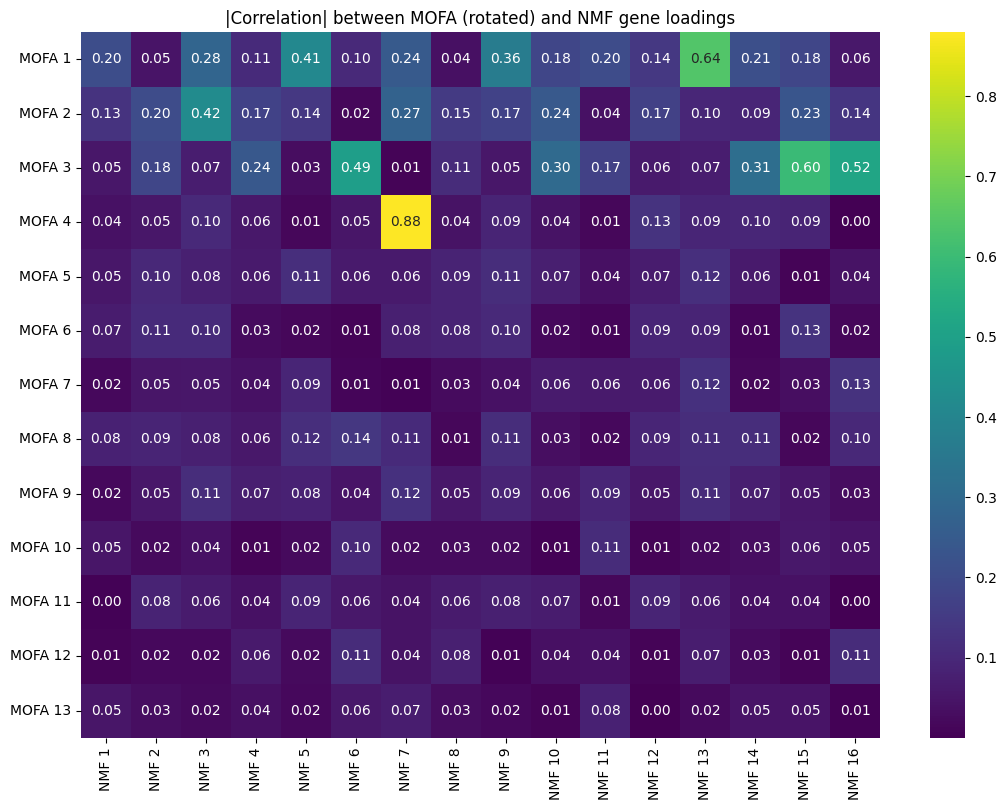

   MOFA_factor NMF_factor  similarity
3       MOFA 4      NMF 7    0.879696
0       MOFA 1     NMF 13    0.640279
2       MOFA 3     NMF 15    0.597729
1       MOFA 2      NMF 3    0.422084
6       MOFA 7     NMF 16    0.126940
4       MOFA 5      NMF 5    0.113696
7       MOFA 8     NMF 14    0.111874
11     MOFA 12      NMF 6    0.109597
9      MOFA 10     NMF 11    0.107240
5       MOFA 6      NMF 2    0.105036
8       MOFA 9      NMF 9    0.088502
10     MOFA 11     NMF 12    0.086608
12     MOFA 13      NMF 1    0.050768


In [75]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.stats import hypergeom
import seaborn as sns
import matplotlib.pyplot as plt

# gene alignment
common_genes = sorted(set(nmf_genes) & set(feat_rna))
print(f"Common genes: {len(common_genes)} (NMF had {len(nmf_genes)}, MOFA RNA had {len(feat_rna)})")

nmf_gene_to_idx = {g: i for i, g in enumerate(nmf_genes)}
mofa_gene_to_idx = {g: i for i, g in enumerate(feat_rna)}

nmf_idx = [nmf_gene_to_idx[g] for g in common_genes]
mofa_idx = [mofa_gene_to_idx[g] for g in common_genes]

# keep only numeric NMF factor columns
nmf_numeric = nmf_loadings.drop(columns=["Unnamed: 0"])

# make numeric matrix
H_nmf = nmf_numeric.iloc[nmf_idx, :].to_numpy(dtype=float)
  
# H_nmf = nmf_loadings.iloc[nmf_idx, :].to_numpy() # common_genes x 16
W_mofa_rna_aligned = W_list_orig[0][mofa_idx, :] # common_genes x n_mofa_factors

n_mofa = W_mofa_rna_aligned.shape[1]
n_nmf = H_nmf.shape[1]  # 16

sim_matrix = np.zeros((n_mofa, n_nmf))
for i in range(n_mofa):
    for j in range(n_nmf):
        sim_matrix[i, j] = np.abs(
            np.corrcoef(W_mofa_rna_aligned[:, i], H_nmf[:, j])[0, 1]
        )

sim_df = pd.DataFrame(
    sim_matrix,
    index=[f"MOFA {i+1}" for i in range(n_mofa)],
    columns=[f"NMF {j+1}" for j in range(n_nmf)]
)

plt.figure(figsize=(0.5*n_nmf+3, 0.4*n_mofa+3))
sns.heatmap(sim_df, cmap="viridis", annot=True, fmt=".2f")
plt.title("|Correlation| between MOFA (rotated) and NMF gene loadings")
plt.tight_layout()
plt.show()

row_ind, col_ind = linear_sum_assignment(-sim_matrix)
matches = pd.DataFrame({
    "MOFA_factor": [f"MOFA {i+1}" for i in row_ind],
    "NMF_factor": [f"NMF {j+1}" for j in col_ind],
    "similarity": sim_matrix[row_ind, col_ind]
}).sort_values("similarity", ascending=False)

print(matches)

In [79]:
# Best NMF match for each MOFA factor (no bijection constraint)
best_nmf_per_mofa = sim_df.idxmax(axis=1)
best_nmf_val = sim_df.max(axis=1)

# Best MOFA match for each NMF factor
best_mofa_per_nmf = sim_df.idxmax(axis=0)
best_mofa_val = sim_df.max(axis=0)

unconstrained = pd.DataFrame({
    "best_NMF_match": best_nmf_per_mofa,
    "correlation": best_nmf_val
}).sort_values("correlation", ascending=False)

print(unconstrained)
print("\nDoes any NMF factor get claimed as 'best' by multiple MOFA factors?")
print(best_nmf_per_mofa.value_counts())

        best_NMF_match  correlation
MOFA 4           NMF 7     0.879696
MOFA 1          NMF 13     0.640279
MOFA 3          NMF 15     0.597729
MOFA 2           NMF 3     0.422084
MOFA 8           NMF 6     0.139051
MOFA 6          NMF 15     0.129397
MOFA 7          NMF 16     0.126940
MOFA 9           NMF 7     0.122578
MOFA 5          NMF 13     0.118769
MOFA 12          NMF 6     0.109597
MOFA 10         NMF 11     0.107240
MOFA 11          NMF 5     0.088051
MOFA 13         NMF 11     0.081078

Does any NMF factor get claimed as 'best' by multiple MOFA factors?
NMF 13    2
NMF 15    2
NMF 7     2
NMF 6     2
NMF 11    2
NMF 3     1
NMF 16    1
NMF 5     1
Name: count, dtype: int64
